# Statistical Analysis: From Exploratory Patterns to Quantitative Evidence

This notebook represents the second stage of the analysis and builds conceptually on the findings obtained during the Exploratory Data Analysis (EDA) phase, while using a separate but thematically related dataset.

In the EDA stage, the distributions and pairwise relationships of key demographic, behavioral, and lifestyle variables were examined in relation to students’ depression status. The exploratory analysis showed that the data were well-structured and free of major quality issues. However, visual comparisons between students with and without depression revealed highly similar distributions across all examined variables. Median values, variability, and tail behavior were closely aligned, and pairwise scatter plots did not suggest clear linear or monotonic relationships.

These results indicated that, while the explored behavioral and lifestyle factors were plausibly related to mental health, any potential associations were likely to be subtle and not readily observable through exploratory visualization alone. In addition, the binary nature of the depression indicator limited the ability to capture more nuanced variation in mental well-being.

For this reason, the current stage proceeds with a different dataset, also based on student survey data, but featuring a continuous mental health measure. This allows the analysis to focus more directly on variation in mental well-being and to apply statistical methods better suited to detecting weak or non-linear associations.

The purpose of the current stage is to move beyond descriptive and visual exploration and to assess whether such subtle patterns are supported by quantitative evidence. Rather than relying on visual separation between groups, this notebook focuses on measuring the strength, form, and robustness of associations using appropriate statistical metrics and tests.

## Research Objective

The objective of this analysis is to statistically evaluate the relationships between students' mental health and behavioral, demographic, and academic factors using both exploratory and inferential statistical methods.

## Research Focus

The central outcome variable in this analysis is `Mental_Health_Score`, a self-reported measure of students’ mental well-being on a scale from 1 (poor) to 10 (excellent). Unlike the binary depression indicator used in the EDA stage, this variable provides a more granular view of mental health and enables a richer analysis of individual differences.

The analysis is guided by the following research questions:

- Is there a statistical association between students’ mental health scores and the amount of time they spend on social media?
- Do mental health scores differ across relationship status groups?
- If associations are present, what is their form: linear, monotonic, or non-linear?
- Are the observed relationships robust when considering related contextual factors such as sleep duration and academic level?

## Analytical Scope and Assumptions

The dataset used in this notebook is based on a cross-sectional student survey conducted across multiple countries and academic levels. All variables are self-reported, and no temporal or experimental structure is available. Consequently, the analysis is explicitly limited to identifying statistical associations rather than inferring causal relationships.

Statistical methods are selected with an emphasis on interpretability and robustness, particularly in settings where effect sizes may be small and distributions may deviate from idealized assumptions. Both visual and quantitative approaches are used to complement each other, with careful attention paid to distributional properties, outliers, and the practical significance of results in addition to formal statistical significance.

## Expected Outcome

By the end of this analysis, the goal is to determine whether the absence of strong visual patterns observed during EDA reflects a genuine lack of association or whether meaningful but subtle relationships can be detected using a more granular mental health measure and formal statistical analysis. The findings from this stage are intended to clarify which factors are plausibly related to students’ mental well-being and to provide a principled foundation for subsequent analytical steps.

In [2]:
# Core libraries
import warnings

import pandas as pd
import numpy as np

from scipy import stats

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# - Warnings / Notebook hygiene -
# -------------------------------

warnings.filterwarnings("ignore") # убирает шум

# ---------------------------
# - Pandas display settings -
# ---------------------------

# Show all columns in DataFrame output
pd.set_option("display.max_columns", None)

# Show maximum column width
pd.set_option("display.max_colwidth", 150)

# Set maximum number of rows
pd.set_option("display.max_rows", 60) 

# Format float numbers
pd.set_option("display.float_format", "{:.2f}".format)

# --------------------
# - Seaborn settings -
# --------------------

# Set overall seaborn theme
sns.set_theme(
  style="whitegrid",
  context="notebook"
)

# -------------------------------
# - Matplotlib default settings -
# -------------------------------

# Set default figure size
plt.rcParams["figure.figsize"]=(10, 6)

# Improve layout so lables don't overlap
plt.rcParams["figure.autolayout"] = True

# DPI for saved images
plt.rcParams["savefig.dpi"] = 150

# --------------------
# - Dataset cleaning -
# --------------------

df = pd.read_csv("../data/Students Social Media Addiction.csv")

df.head()

df.sample(8)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
398,399,20,Female,Undergraduate,France,3.80,Instagram,No,8.20,7,In Relationship,2,5
113,114,22,Female,Graduate,Pakistan,5.50,Instagram,Yes,6.00,5,Single,4,8
411,412,22,Male,Graduate,Denmark,3.10,Facebook,No,8.70,8,In Relationship,2,4
347,348,22,Male,Graduate,Mexico,5.80,WhatsApp,Yes,6.40,6,Single,3,7
512,513,19,Female,Undergraduate,Netherlands,3.70,TikTok,No,8.30,8,Single,2,4
192,193,19,Female,Undergraduate,Nepal,6.00,TikTok,Yes,5.00,6,Single,4,8
239,240,22,Male,Graduate,Germany,4.10,Facebook,No,7.70,8,In Relationship,2,4
305,306,21,Male,Graduate,Italy,5.00,Instagram,Yes,7.10,5,Single,3,7


The dataset is based on survey responses from students and contains demographic, academic, and behavioral information. It includes variables describing age, gender, country, and academic level, as well as self-reported lifestyle characteristics such as sleep duration, average daily time spent on social media, relationship status, mental health score, and social media addiction level. The data are cross-sectional and reflect students’ subjective assessments at a single point in time.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

The dataset consists of 705 observations and 13 features. It includes numerical variables (both integer and continuous) as well as categorical variables represented as text labels. No missing values are present, and the data types are consistent with the semantics of the corresponding features, indicating adequate data quality for statistical analysis.

The primary outcome (target) variable of the analysis is `Mental_Health_Score`, a self-reported measure of students’ mental well-being. The key explanatory variables of interest are `Avg_Daily_Usage_Hours`, reflecting social media usage intensity, and `Relationship_Status`, capturing students’ relationship context. Additional contextual variables used to support interpretation include `Sleep_Hours_Per_Night`, `Addicted_Score`, `Age`, and `Academic_Level`. These features are treated as potential explanatory or control variables when examining associations with mental health.

In [4]:
# ----------------------------------------------
# - Distribution diagnostics for key variables -
# ----------------------------------------------

df["Mental_Health_Score"].describe()
iqr = 7 - 5 # 2

Text(0, 0.5, 'Count')

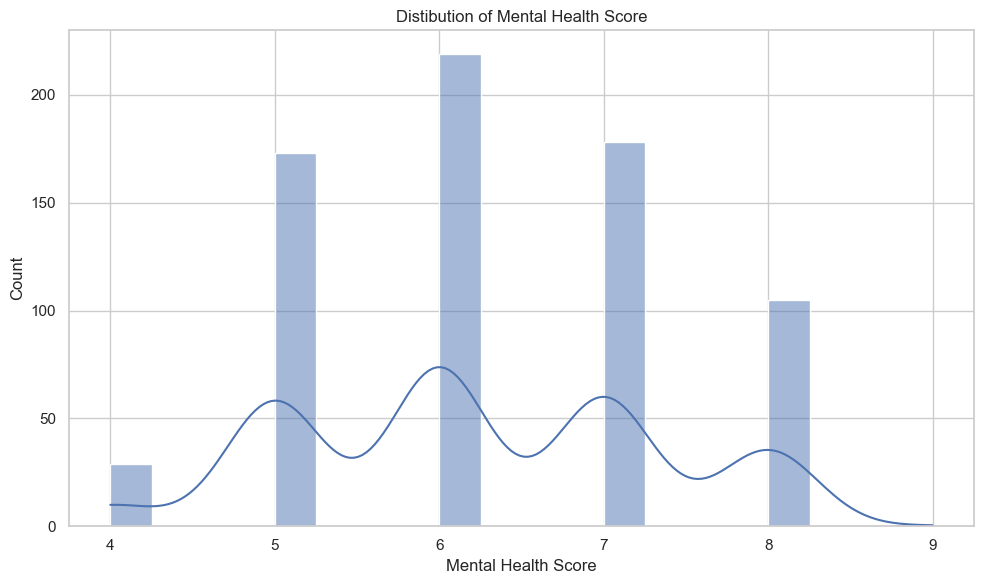

In [5]:
sns.histplot(
  data=df,
  x="Mental_Health_Score",
  bins=20,
  kde=True
)

plt.title('Distibution of Mental Health Score')
plt.xlabel("Mental Health Score")
plt.ylabel("Count")

Text(0.5, 0, 'Mental Health Score')

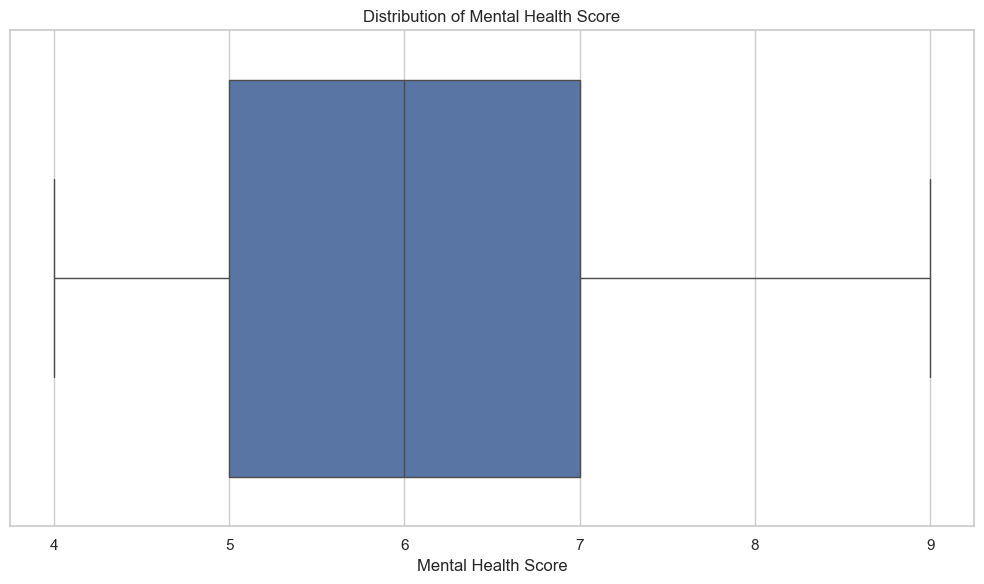

In [6]:
sns.boxplot(
  data=df,
  x="Mental_Health_Score"
)

plt.title("Distribution of Mental Health Score")
plt.xlabel("Mental Health Score")
# Сторили не просто так, а для:
# 1) проверки выбросов - boxplot показывает точки вне 1.5 IQR
# 2) проверки перекоса - если бы медиана была ближе к краю box - была бы ассиметрия
# 3) быстрой проверки концентрации - узкий box -> сконцентрированы  

In [7]:
df["Mental_Health_Score"].skew() # skew измеряет ассиметрию распредлений
# То есть, насколько распределение отклняется от симетричной формы
# распределение симметрично - skew = 0
# длинный хвост вправо - skew > 0
# длинный хвост влево - skew < 0 

np.float64(0.049022622911663795)

In [8]:
df["Mental_Health_Score"].value_counts().sort_index()

Mental_Health_Score
4     29
5    173
6    219
7    178
8    105
9      1
Name: count, dtype: int64

The distribution of Mental_Health_Score is approximately symmetric (skew ≈ 0.05), with the majority of observations concentrated in the 5–7 range. No extreme outliers or ceiling/floor effects are observed. Given the sufficient variability and near-symmetric shape, the variable can reasonably be treated as quasi-continuous for the purposes of correlation and group comparison analysis. In particular, the absence of strong skewness or extreme values supports the use of Pearson correlation to assess linear associations, while Spearman correlation will additionally be computed to evaluate potential monotonic relationships.

In [9]:
df["Avg_Daily_Usage_Hours"].describe()
iqr = 8.5 - 4.1 # 4.4

Text(0, 0.5, 'Count')

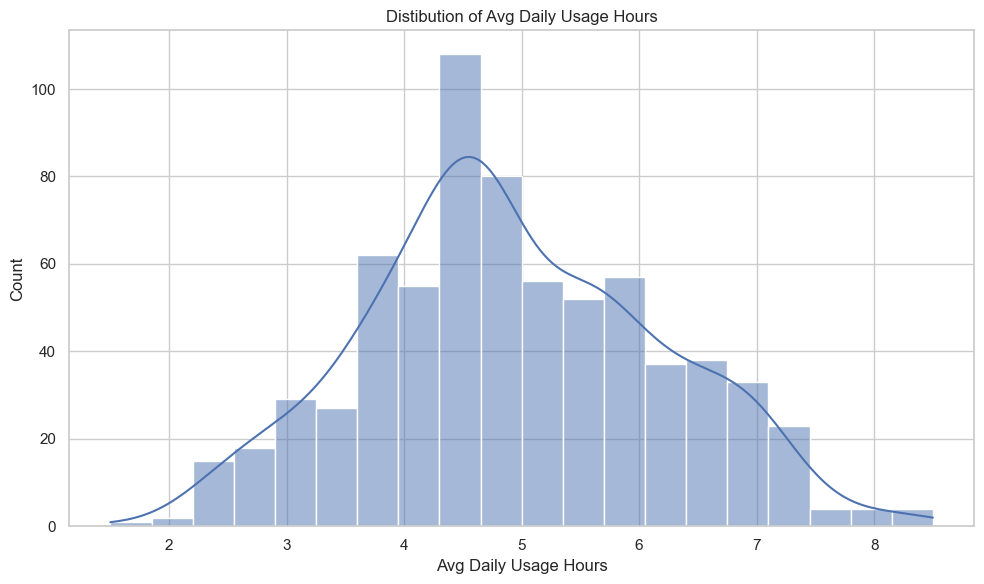

In [10]:
sns.histplot(
  data=df,
  x="Avg_Daily_Usage_Hours",
  bins=20,
  kde=True
)

plt.title('Distibution of Avg Daily Usage Hours')
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Count")

Text(0.5, 0, 'Avg Daily Usage Hours')

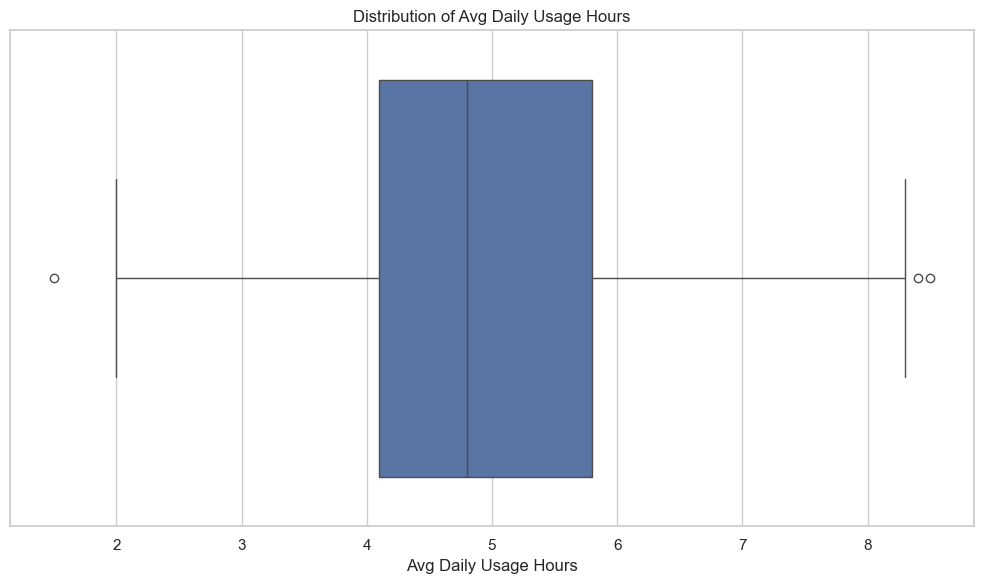

In [11]:
sns.boxplot(
  data=df,
  x="Avg_Daily_Usage_Hours"
)

plt.title("Distribution of Avg Daily Usage Hours")
plt.xlabel("Avg Daily Usage Hours")

In [12]:
df["Avg_Daily_Usage_Hours"].skew()

np.float64(0.16463375853781276)

The distribution of `Avg_Daily_Usage_Hours` is approximately symmetric (skew ≈ 0.16) with no substantial outliers. The central 50% of observations fall between 4.1 and 5.8 hours per day, indicating moderate and relatively concentrated social media usage among most students. The observed variability (SD ≈ 1.26) is sufficient to allow meaningful correlation analysis. Given the near-symmetric shape and absence of extreme skewness, both Pearson and Spearman correlations can be appropriately applied in subsequent analysis.

In [13]:
iqr = 7.7 - 6 # 1.7
variation_coeff = 1.13 / 6.87 # 0.16448326055312953
df["Sleep_Hours_Per_Night"].describe()

count   705.00
mean      6.87
std       1.13
min       3.80
25%       6.00
50%       6.90
75%       7.70
max       9.60
Name: Sleep_Hours_Per_Night, dtype: float64

Text(0, 0.5, 'Count')

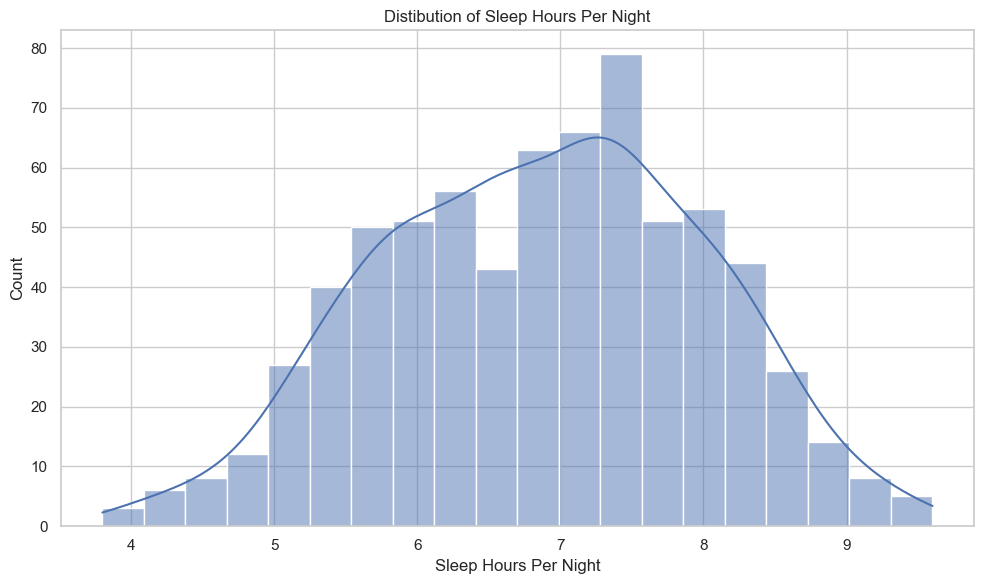

In [14]:
sns.histplot(
  data=df,
  x="Sleep_Hours_Per_Night",
  bins=20,
  kde=True
)

plt.title('Distibution of Sleep Hours Per Night')
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Count")

Text(0.5, 0, 'Sleep Hours Per Night')

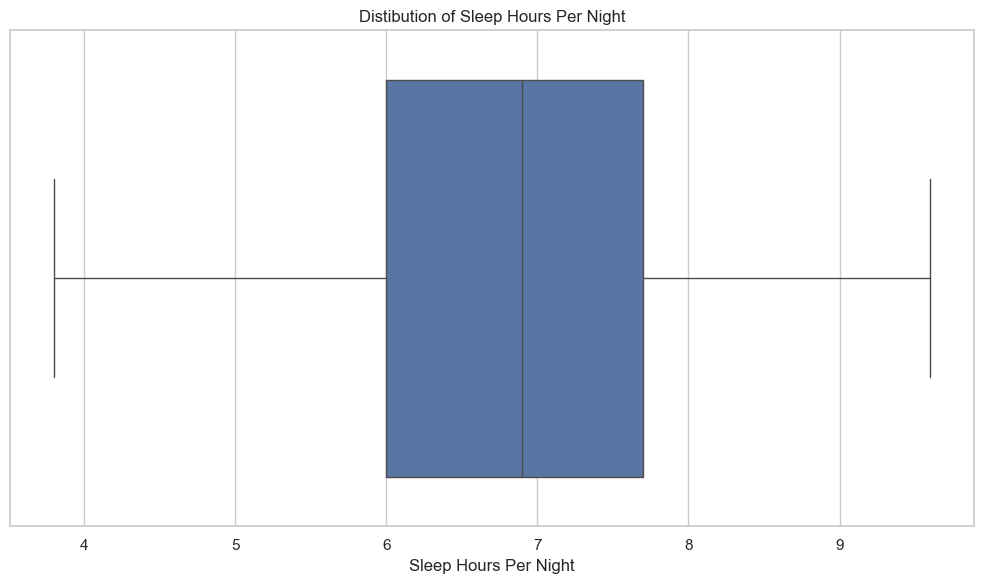

In [15]:
sns.boxplot(
  data=df,
  x="Sleep_Hours_Per_Night"
)

plt.title('Distibution of Sleep Hours Per Night')
plt.xlabel("Sleep Hours Per Night")

In [16]:
df["Sleep_Hours_Per_Night"].skew()

np.float64(-0.1090403313627565)

The distribution of `Sleep_Hours_Per_Night` is approximately symmetric (skew ≈ -0.11), with mean and median closely aligned. The central 50% of observations fall between 6.0 and 7.7 hours, indicating that most students report sleep durations within a relatively narrow and realistic range. No substantial outliers are observed. The variability (SD ≈ 1.13) is moderate and sufficient to allow meaningful association analysis. Given the near-symmetric shape and absence of extreme skewness, Pearson correlation can be appropriately applied, while Spearman correlation may be used as a robustness check. Importantly, sleep duration may also act as a contextual or mediating variable when examining the relationship between social media usage and mental health.

Analyzing relationship: Avg_Daily_Usage_Hours ~ Mental_Health_Score
Number of observations: 705



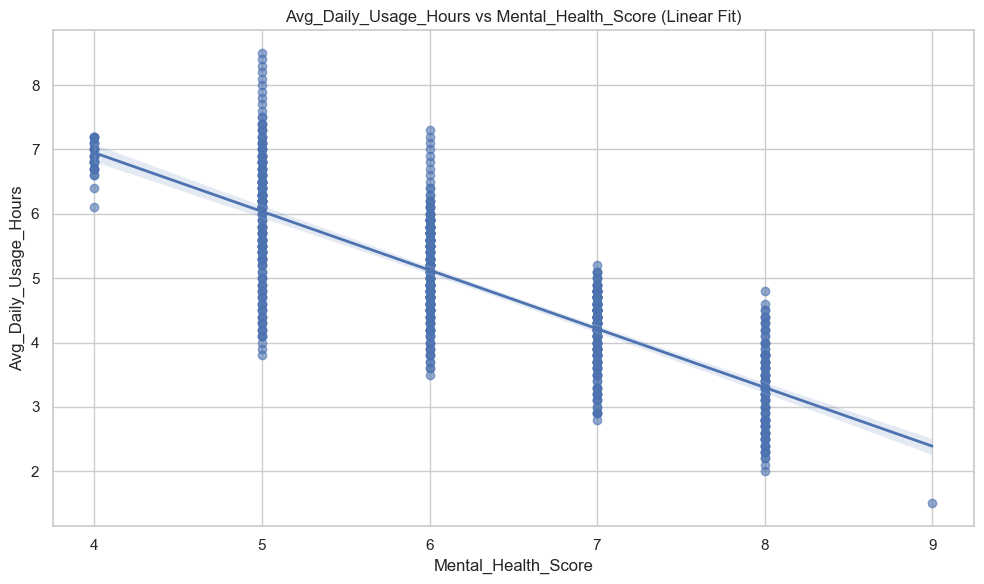

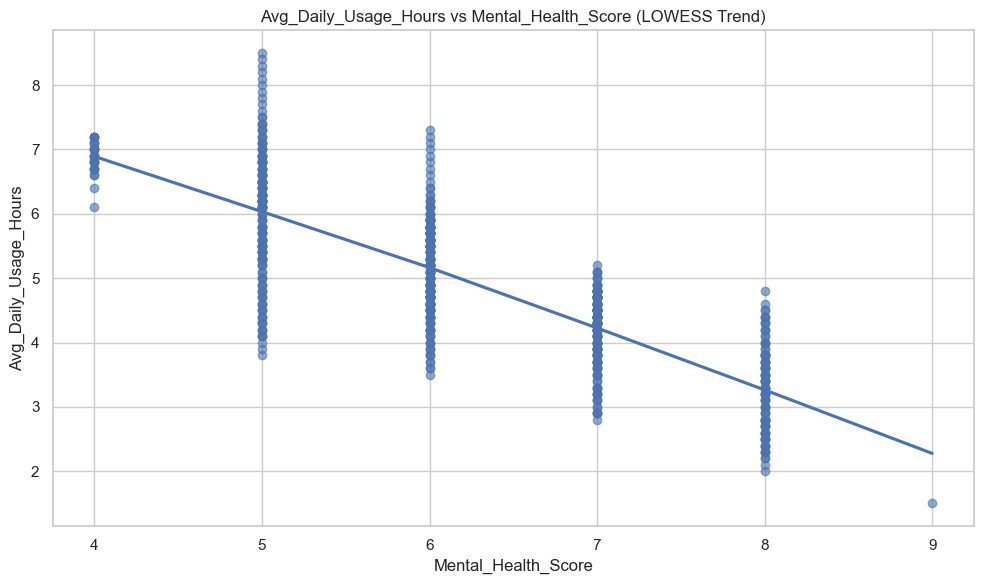

Correlatin Result
Pearson r = -0.801 | p-value = 7.851e-159
Spearman r = -0.802 | p-value = 2.196e-159

Interpretation
----------------------------------------------------------------------
Peason strength: very strong
Spearman strength: very strong
Pearson and Spearman similar → relationship likely linear or uniformly weak.


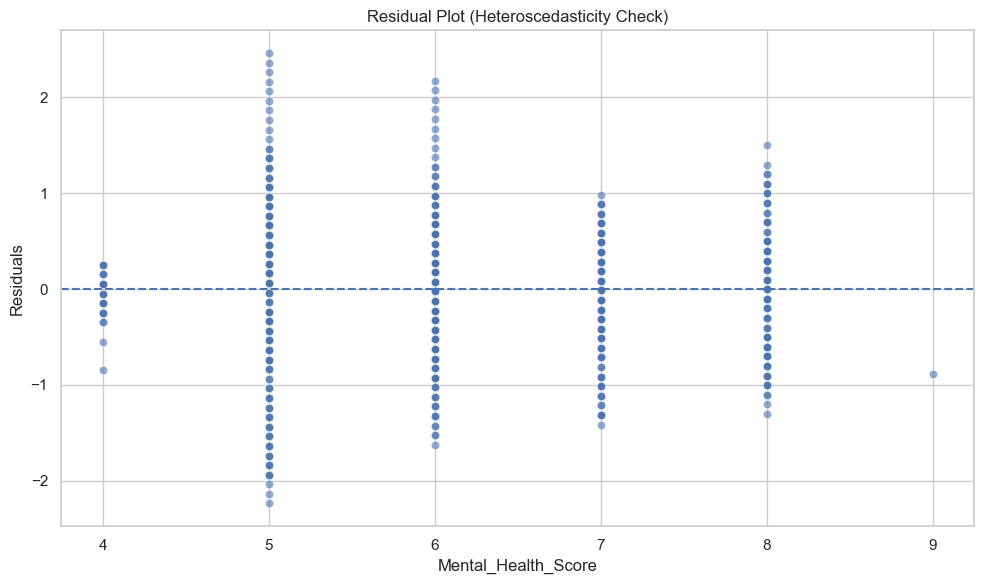


Look at residual plot:
- If spread increases with X → heteroscedasticity possible.
- If residuals are randomly scattered → homoscedasticity likely.


In [ ]:
# -------------------------------------
# - Numerical–numerical relationships -
# -------------------------------------

# -----------------------------------------------------------------
# Function: analyze_relationships 
# Purpose: Visual and statistical analysis of two numeric variables
# -----------------------------------------------------------------

def analyze_relationships(df, x_col, y_col):
  
  print("="*70)
  print(f"Analyzing relationship: {y_col} ~ {x_col}")
  print("="*70)

  # 1. Prepare data
  data = df[[x_col, y_col]].dropna().copy()

  x = data[x_col]
  y = data[y_col]

  print(f"Number of observations: {len(data)}\n")

  # 2. Scatter + Linear Regression Line
  plt.figure(figsize=(10, 6))
  sns.regplot(
    data=data,
    x=x,
    y=y,
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
  )

  plt.title(f"{y_col} vs {x_col} (Linear Fit)")
  plt.show()

  # 3. LOWESS (non-linear trend vizualization)
  plt.figure(figsize=(10, 6))
  sns.regplot(
    data=data,
    x=x_col,
    y=y_col,
    lowess=True,
    scatter_kws={"alpha": 0.6}
  )

  plt.title(f"{y_col} vs {x_col} (LOWESS Trend)")
  plt.show()

  # 4. Pearson & Spearman correlation
  pearson_r, pearson_p = stats.pearsonr(x, y)
  spearman_r, spearman_p = stats.spearmanr(x, y)

  print("Correlatin Result")
  print("="*70)
  print(f"Pearson r = {pearson_r:.3f} | p-value = {pearson_p:.4g}")
  print(f"Spearman r = {spearman_r:.3f} | p-value = {spearman_p:.4g}")

  # 5. Heuristic interpretation
  def strength(val):
    a = abs(val)
    if a < 0.1:
      return "very week"
    elif a < 0.3:
      return "week"
    elif a < 0.5:
      return "moderate"
    elif a < 0.7:
      return "strong"
    else:
      return "very strong"
    
  print("\nInterpretation")
  print("-"*70)
  print(f"Peason strength: {strength(pearson_r)}")
  print(f"Spearman strength: {strength(spearman_r)}")

  if abs(spearman_r) - abs(pearson_r) > 0.1:
    print("Spearman noticeably stronger → possible non-linear monotonic relationship.")
  else:
    print("Pearson and Spearman similar → relationship likely linear or uniformly weak.")

  # 6. Residual plot (heteroscedasticity check)
  slope, intercept, _, _, _ = stats.linregress(x, y)
  y_pred = intercept + slope * x
  residuals = y - y_pred

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=x, y=residuals, alpha=0.6)
  plt.axhline(0, linestyle="--")
  plt.title("Residual Plot (Heteroscedasticity Check)")
  plt.xlabel(x_col)
  plt.ylabel("Residuals")
  plt.show()
  print("\nLook at residual plot:")
  print("- If spread increases with X → heteroscedasticity possible.")
  print("- If residuals are randomly scattered → homoscedasticity likely.")
    
  print("="*70)

analyze_relationships(df, "Mental_Health_Score", "Avg_Daily_Usage_Hours")

### Hypothesis: Mental Health vs Daily Social Media Usage

H0: There is no association between Mental_Health_Score and Avg_Daily_Usage_Hours.

H1: There is a association between these variables.

A strong negative linear association is observed between Mental_Health_Score and Avg_Daily_Usage_Hours (Pearson r = -0.80, p < 0.001). The nearly identical Spearman coefficient (rho = -0.80) suggests that the relationship is both monotonic and approximately linear. Visual inspection confirms a consistent downward trend, with no substantial evidence of non-linearity or heteroscedasticity. The magnitude of the correlation indicates a substantial association between increased social media usage and lower mental health scores within the sample.

Analyzing relationship: Sleep_Hours_Per_Night ~ Mental_Health_Score
Number of observations: 705



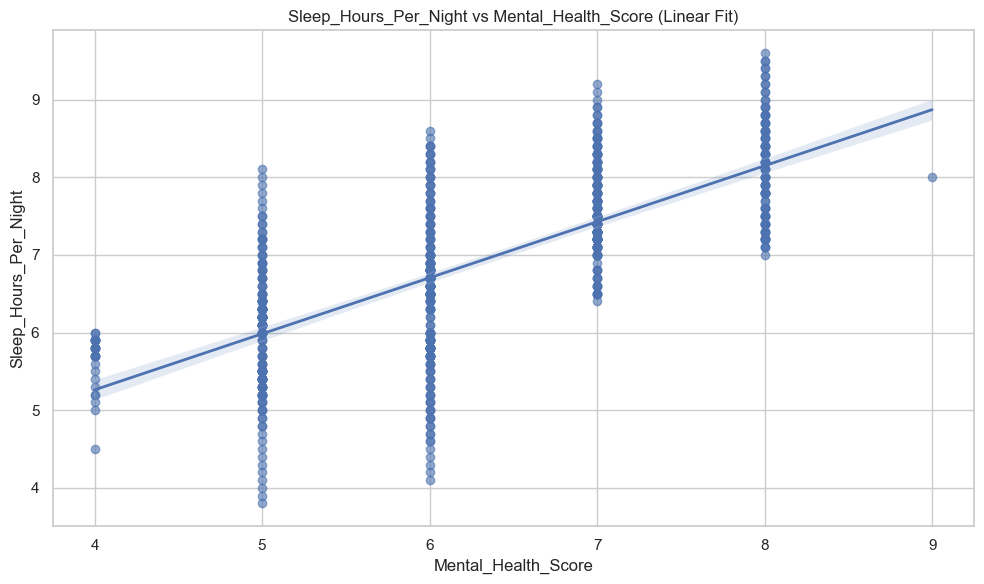

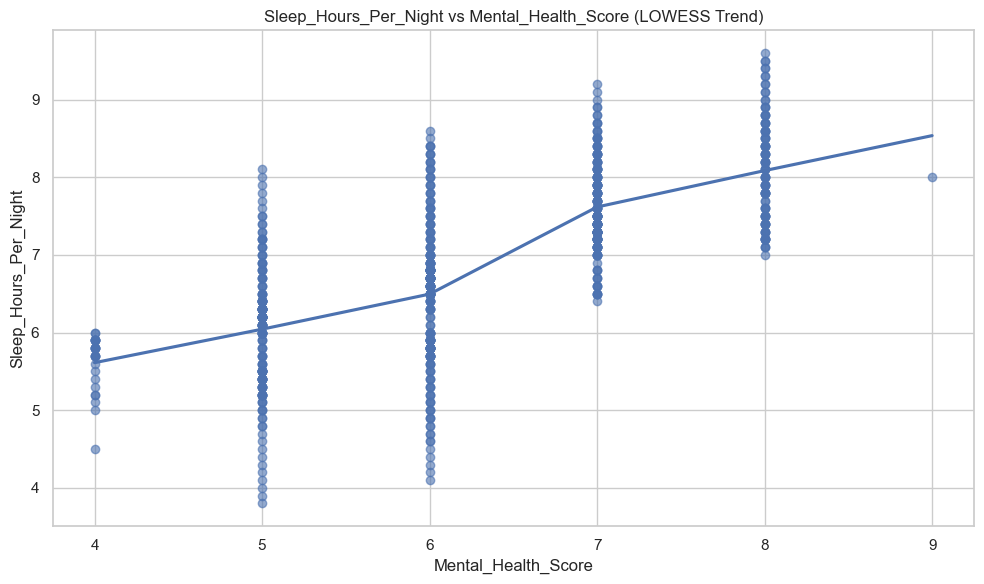

Correlatin Result
Pearson r = 0.707 | p-value = 4.705e-108
Spearman r = 0.734 | p-value = 3.954e-120

Interpretation
----------------------------------------------------------------------
Peason strength: very strong
Spearman strength: very strong
Pearson and Spearman similar → relationship likely linear or uniformly weak.


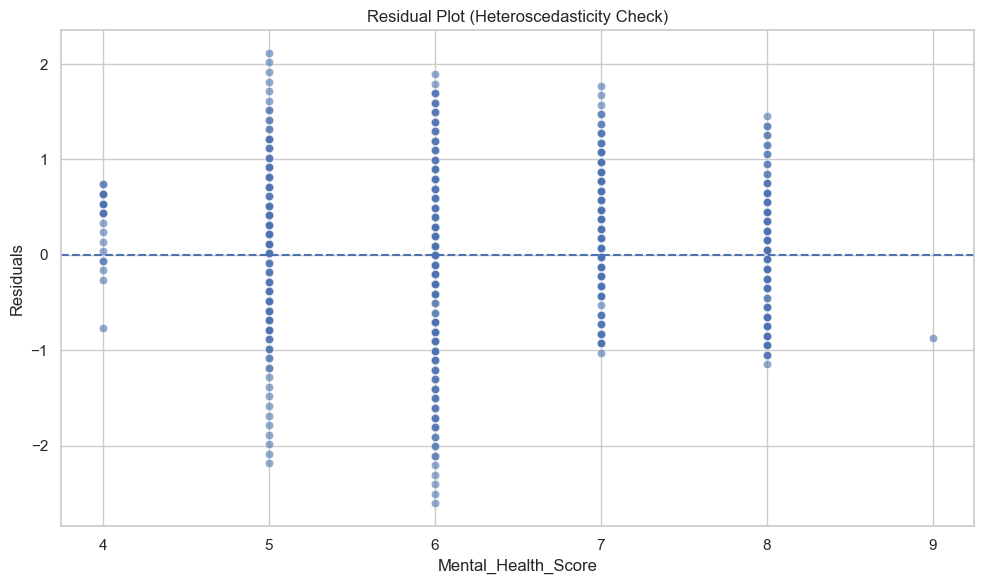


Look at residual plot:
- If spread increases with X → heteroscedasticity possible.
- If residuals are randomly scattered → homoscedasticity likely.


In [19]:
analyze_relationships(df, "Mental_Health_Score", "Sleep_Hours_Per_Night")

### Hypothesis: Mental Health vs Sleep Hours Per Night

H0: The linear correlation between Mental_Health_Score and Sleep_Hours_Per_Night equals zero (r = 0).

H1: The linear correlation between Mental_Health_Score and Sleep_Hours_Per_Night is not zero (r ≠ 0).

A strong positive association is observed between Mental_Health_Score and Sleep_Hours_Per_Night (Pearson r = 0.71, p < 0.001). The Spearman coefficient (rho = 0.73) is slightly higher but comparable in magnitude, indicating that the relationship is both monotonic and approximately linear. Visual inspection of the scatterplot confirms a consistent upward trend across mental health levels. The residual plot does not show systematic patterns or funnel-shaped dispersion, suggesting that the assumption of homoscedasticity is reasonably satisfied. Overall, higher mental health scores are associated with longer sleep duration within the sample.

Analyzing relationship: Addicted_Score ~ Mental_Health_Score
Number of observations: 705



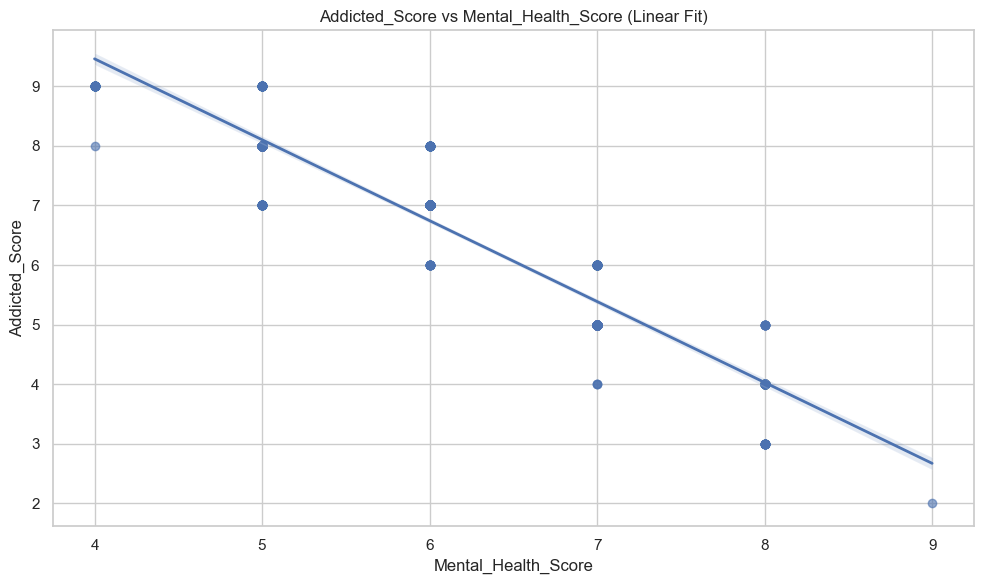

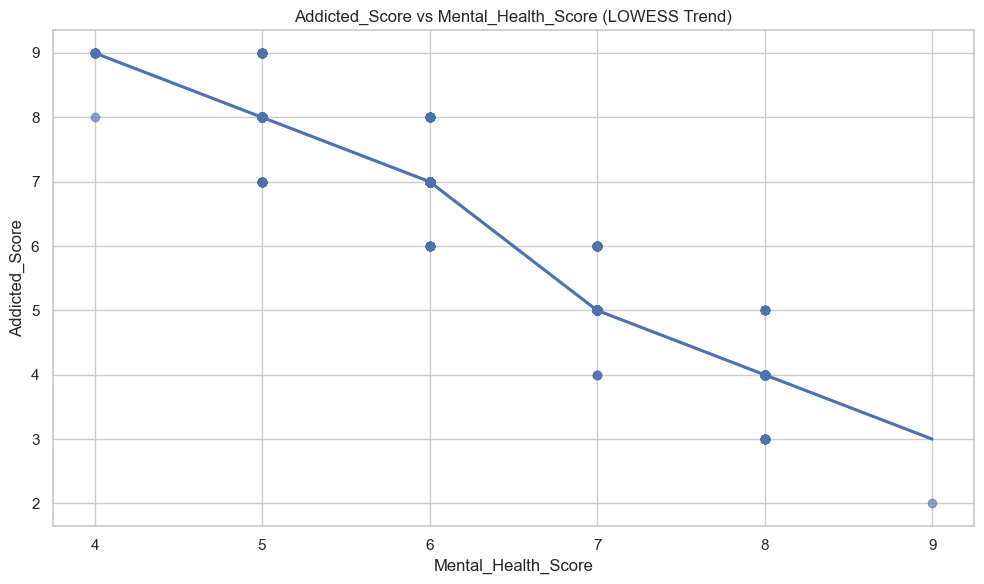

Correlatin Result
Pearson r = -0.945 | p-value = 0
Spearman r = -0.950 | p-value = 0

Interpretation
----------------------------------------------------------------------
Peason strength: very strong
Spearman strength: very strong
Pearson and Spearman similar → relationship likely linear or uniformly weak.


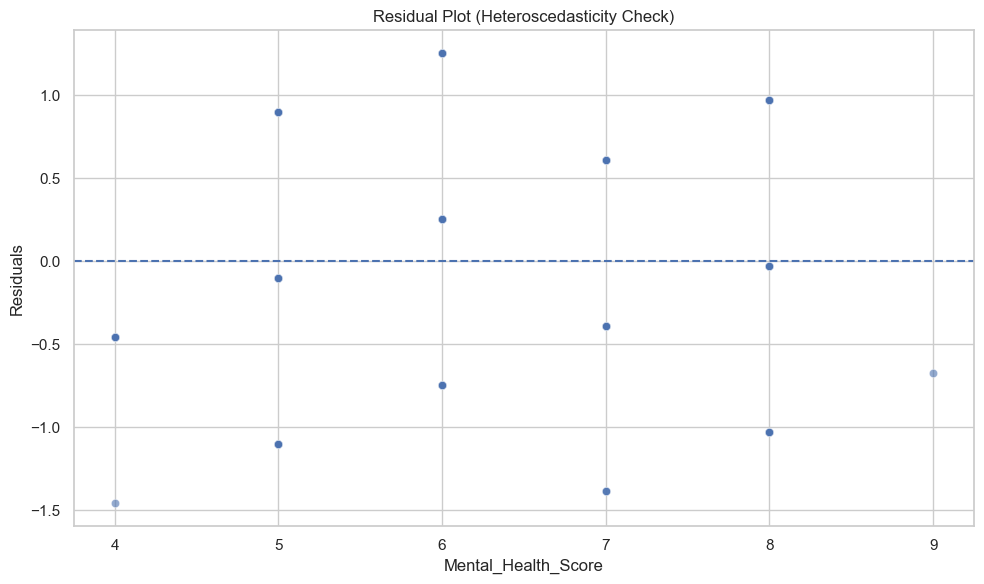


Look at residual plot:
- If spread increases with X → heteroscedasticity possible.
- If residuals are randomly scattered → homoscedasticity likely.


In [20]:
analyze_relationships(df, "Mental_Health_Score", "Addicted_Score")

### Hypothesis: Mental Health vs Social Media Addiction

H0: The linear correlation between Mental_Health_Score and Addicted_Score equals zero (r = 0).

H1: The linear correlation between Mental_Health_Score and Addicted_Score is not zero (r ≠ 0).

A very strong negative linear relationship is observed between social media addiction and mental health (r ≈ -0.95, p < 0.001). Pearson and Spearman coefficients are nearly identical, indicating a stable monotonic and linear association. Residual analysis does not reveal heteroscedasticity or systematic structure, suggesting that a linear model adequately captures the relationship. However, the magnitude of the correlation is unusually high for behavioral data, and the result should be interpreted as association rather than causation.

Analyzing relationship: Mental_Health_Score ~ Relationship_Status
Number of observations: 705

Number of groups: 3

Group sizes: Relationship_Status
Single             384
In Relationship    289
Complicated         32
Name: count, dtype: int64

Stats table:


,count,mean,median,std
Relationship_Status,,,,
Complicated,32,5.94,6.00,1.08
In Relationship,289,6.30,6.00,1.09
Single,384,6.20,6.00,1.12


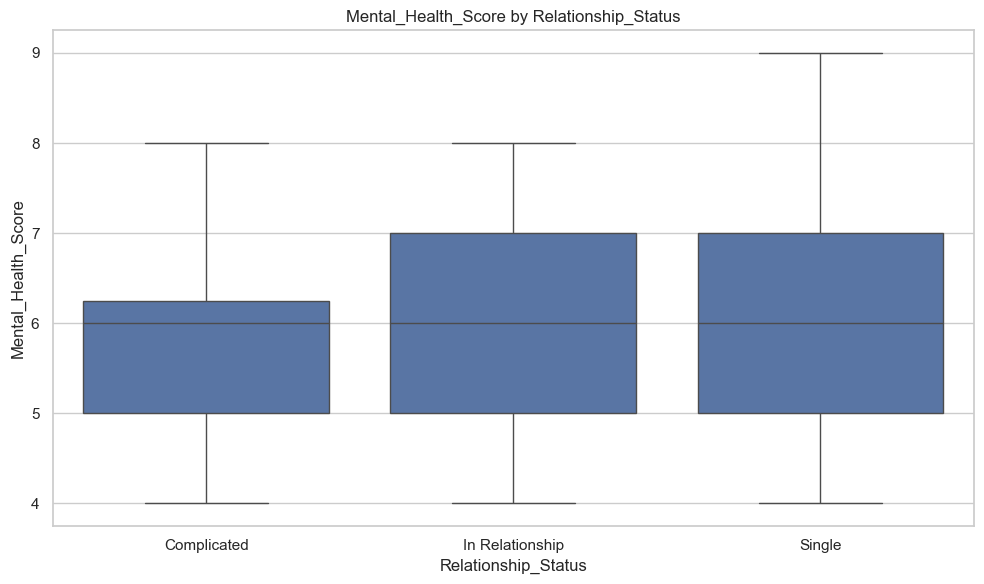

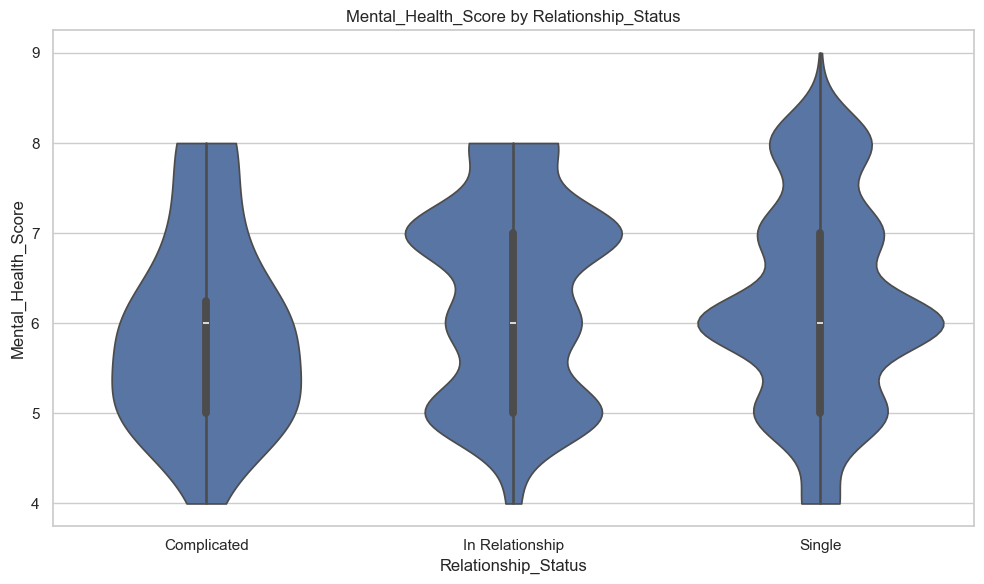


Test results
Kruskal-Wallis H = 4.133 | p_value = 0.1266
Epsilon-squared (effect size) = 0.003

Interpretation
No statistically significant differences detected (p ≥ 0.05).
Effect size is very small (practically week differences).


In [ ]:
# ---------------------------------------
# - Categorical–numerical relationships -
# ---------------------------------------

# -----------------------------------------------------------------
# Function: analyze_group_difference 
# Purpose: Visual and statistical analysis of categorical and numeric variables
# -----------------------------------------------------------------
def analyze_group_difference(df, y_col, group_col):

  print("="*70)
  print(f"Analyzing relationship: {y_col} ~ {group_col}")
  print("="*70)

  # 1. Prepare data
  data = df[[y_col, group_col]].dropna().copy()

  y = y_col
  category = group_col

  n_groups = data[category].nunique()

  print(f"Number of observations: {len(data)}\n")
  print(f"Number of groups: {n_groups}\n")
  print(f"Group sizes: {data[category].value_counts()}\n")

  # 2. Mini-table with key stats
  stats_table = data.groupby(category)[y].agg(["count", "mean", "median", "std"])
  print("Stats table:")
  display(stats_table)

  # 3. Visualization

  order = (
    data.groupby(category)[y]
    .median()
    .sort_values()
    .index
  )

  plt.figure(figsize=(10, 6))
  sns.boxplot(
    data=data,
    x=category,
    y=y,
    order=order 
  )
  plt.title(f"{y} by {category}")
  plt.show()

  plt.figure(figsize=(10, 6))
  sns.violinplot(
    data=data,
    x=category,
    y=y,
    inner="box",
    cut=0,
    order=order
  )
  plt.title(f"{y} by {category}")
  plt.show()

  # 4. Statistical test + p-value (depends on number of groups)
  from scipy import stats

  n = len(data)
  k = data[category].nunique()

  grouped = [g[y].values for _, g in data.groupby(category)]

  print("\nTest results")
  print("="*70)

  if k == 2:
    # Mann-Whitney U test for two independent groups
    u_stat, p_value = stats.mannwhitneyu(grouped[0], grouped[1], alternative="two-sided")
    print(f"Mann-Whitney U = {u_stat:.3f} | p_value = {p_value:.4g}")

    # Simple effect proxy: median difference
    medians = data.groupby(category)[y].median().sort_values()
    median_gap = medians.iloc[1] - medians.iloc[0]
    print(f"Median difference = {median_gap:.3f}")

  else:
    # Kruskal-Wallis test for 3+ independent groups
    h_stat, p_value = stats.kruskal(*grouped)
    print(f"Kruskal-Wallis H = {h_stat:.3f} | p_value = {p_value:.4g}")

    # Effect size: epsilon squared
    eps2 = (h_stat - k + 1) / (n - k)
    print(f"Epsilon-squared (effect size) = {eps2:.3f}")

  # 5. Interpretation helper
  alpha = 0.05
  print("\nInterpretation")
  print("=" * 70)

  if p_value < alpha:
    print("There is evidence of differences between groups (p < 0.05).")
  else:
    print("No statistically significant differences detected (p ≥ 0.05).")

  if k > 2:
    if eps2 < 0.01:
      print("Effect size is very small (practically week differences).")
    elif eps2 < 0.06:
      print("Effect size is small")
    elif eps2 < 0.14:
      print("Effect size is moderate")
    else:
      print("Effect size is large")

analyze_group_difference(df, "Mental_Health_Score", "Relationship_Status")

### Hypothesis: Mental Health vs Relationship Status

H0: The distributions of Mental_Health_Score are the same across all Relationship_Status groups.

H1: At least one group has a different distribution.

Although minor differences in mean scores are observed across relationship status categories, the medians are identical and distributions strongly overlap. The Kruskal–Wallis test does not indicate statistically significant differences (p = 0.127), and the effect size is negligible (ε² = 0.003). Therefore, relationship status does not appear to meaningfully influence mental health score in this sample.

Analyzing relationship: Mental_Health_Score ~ Academic_Level
Number of observations: 705

Number of groups: 3

Group sizes: Academic_Level
Undergraduate    353
Graduate         325
High School       27
Name: count, dtype: int64

Stats table:


,count,mean,median,std
Academic_Level,,,,
Graduate,325,6.37,6.00,1.07
High School,27,5.11,5.00,0.58
Undergraduate,353,6.18,6.00,1.12


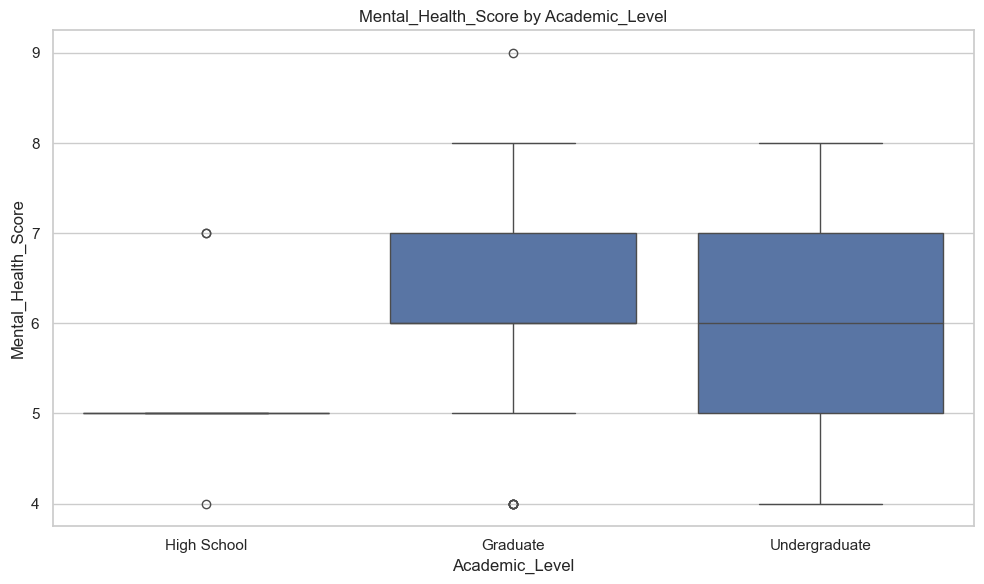

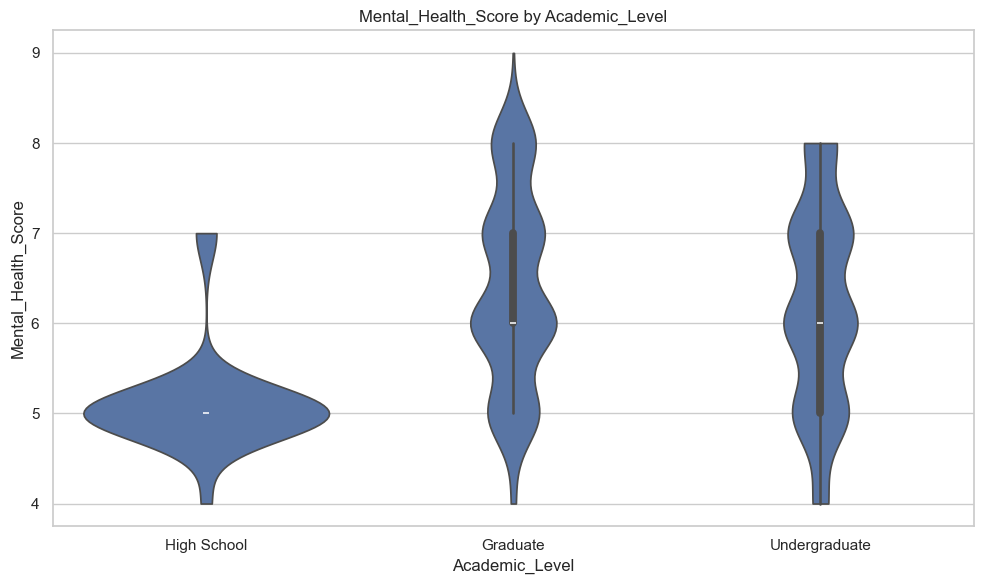


Test results
Kruskal-Wallis H = 36.503 | p_value = 1.185e-08
Epsilon-squared (effect size) = 0.049

Interpretation
There is evidence of differences between groups (p < 0.05).
Effect size is small


In [24]:
analyze_group_difference(df, "Mental_Health_Score", "Academic_Level")

### Hypothesis: Mental Health vs Academic Level

H0: The distributions of Mental_Health_Score are the same across all Academic_Level groups.

H1: At least one group has a different distribution.

Mental Health Score differs significantly across Academic Level groups (Kruskal–Wallis H = 36.50, p < 0.001).
However, the effect size is small (ε² = 0.049), indicating that academic level explains only a small proportion of variance in mental health scores.
High School students demonstrate slightly lower median scores compared to Undergraduate and Graduate groups, though distributions substantially overlap.
Academic level statistically relates to mental health score, but the practical magnitude of this difference is small. The primary contrast appears between High School and the other groups, while Graduate and Undergraduate students show very similar distributions.

Chi-square analysis


Academic_Level,Graduate,High School,Undergraduate
Relationship_Status,,,
Complicated,0.16,0.28,0.56
In Relationship,0.56,0.02,0.42
Single,0.41,0.03,0.56



Chi-square test
Chi-square statistic: 0.644
p-value: 0.95802
Degree of freedom: 4

Expected frequency table


Academic_Level,Graduate,High School,Undergraduate
Relationship_Status,,,
Complicated,0.38,0.11,0.51
In Relationship,0.38,0.11,0.51
Single,0.38,0.11,0.51



Cramér's V effect
Cramér's V: 0.328

Visualization


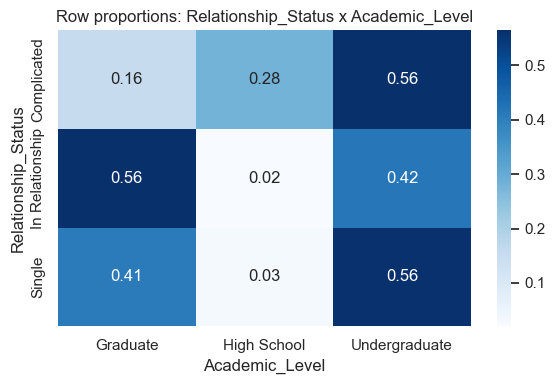


Residuals


Academic_Level,Graduate,High School,Undergraduate
Relationship_Status,,,
Complicated,-0.36,0.51,0.07
In Relationship,0.31,-0.27,-0.14
Single,0.05,-0.24,0.07


In [ ]:
# ----------------------------------------------
# - Categorial-categorial(chi-square) analysis -
# ----------------------------------------------

# -----------------------------------------------------------------
# Function: chi_square_analysis 
# Purpose: Statistical analysis of two categorical variables
# -----------------------------------------------------------------
def chi_square_analysis(df, first_group, second_group):
  
  print("="*70)
  print("Chi-square analysis")
  print("="*70)

  # 1. Prepare data
  table = pd.crosstab(df[first_group], df[second_group], normalize="index")
  display(table)

  # 2. Chi-square test
  print("\nChi-square test")
  print("="*70)

  from scipy.stats import chi2_contingency

  chi2, p, dof, expected = chi2_contingency(table)

  print(f"Chi-square statistic: {chi2:.3f}")
  print(f"p-value: {p:.5f}")
  print(f"Degree of freedom: {dof}")

  # 3. Expected frequency check
  print("\nExpected frequency table")
  print("="*70)

  expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
  )

  display(expected_df)

  # 4. Size of Cramér's V effect
  print("\nCramér's V effect")
  print("="*70)

  n = table.values.sum()
  k = min(table.shape)

  cramers_v = np.sqrt(chi2 / (n * (k - 1)))

  print(f"Cramér's V: {cramers_v:.3f}")

  # 5. Visualization
  print("\nVisualization")
  print("="*70)

  plt.figure(figsize=(6, 4))
  sns.heatmap(table, annot=True, fmt=".2f", cmap="Blues")
  plt.title(f"Row proportions: {first_group} x {second_group}")
  plt.show()

  # 6. Residuals(optional)
  print("\nResiduals")
  print("="*70)

  residuals = (table - expected) / np.sqrt(expected)
  display(residuals)
  
chi_square_analysis(df, "Relationship_Status", "Academic_Level")

Chi-square analysis


Gender,Female,Male
Relationship_Status,,
Complicated,0.53,0.47
In Relationship,0.48,0.52
Single,0.52,0.48



Chi-square test
Chi-square statistic: 0.006
p-value: 0.99695
Degree of freedom: 2

Expected frequency table


Gender,Female,Male
Relationship_Status,,
Complicated,0.51,0.49
In Relationship,0.51,0.49
Single,0.51,0.49



Cramér's V effect
Cramér's V: 0.045

Visualization


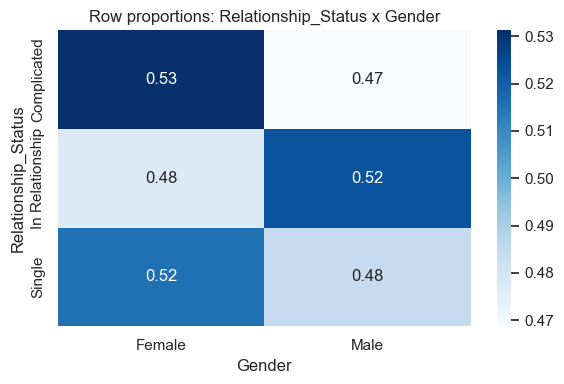


Residuals


Gender,Female,Male
Relationship_Status,,
Complicated,0.03,-0.03
In Relationship,-0.04,0.04
Single,0.01,-0.01


In [34]:
chi_square_analysis(df, "Relationship_Status", "Gender")

### Category ↔ Category Analysis (Chi-square Test)

### Relationship_Status × Academic_Level

### Contingency Table (Row Proportions)

| Relationship Status | Graduate | High School | Undergraduate |
|--------------------|----------|------------|--------------|
| Complicated        | 0.16     | 0.28       | 0.56         |
| In Relationship    | 0.56     | 0.02       | 0.42         |
| Single             | 0.41     | 0.03       | 0.56         |

---

### Chi-square Test Results

- **Chi-square statistic (χ²)** = 0.644  
- **Degrees of freedom** = 4  
- **p-value** = 0.958  

Since p-value >> 0.05, we fail to reject the null hypothesis of independence.

---

### Effect Size (Cramér’s V)

- **Cramér’s V = 0.328**

Interpretation guideline:
- ~0.1 → weak  
- ~0.3 → moderate  
- ~0.5+ → strong  

Despite a moderate numerical value of Cramér’s V, the very high p-value indicates that the observed differences are not statistically significant.

---

### Standardized Residuals

All residuals are close to 0 (between −0.36 and 0.51), which means:

- No cell strongly deviates from expected frequencies  
- No specific combination of categories drives the association  

---

### Interpretation

There is **no statistically significant association** between Academic Level and Relationship Status.

Although row proportions differ slightly, these differences are consistent with random variation.

---

---

### Relationship_Status × Gender

### Contingency Table (Row Proportions)

| Relationship Status | Female | Male |
|--------------------|--------|------|
| Complicated        | 0.53   | 0.47 |
| In Relationship    | 0.48   | 0.52 |
| Single             | 0.52   | 0.48 |

Proportions are nearly identical across categories.

---

### Chi-square Test Results

- **Chi-square statistic (χ²)** = 0.006  
- **Degrees of freedom** = 2  
- **p-value** = 0.99695  

Since p-value >> 0.05, we fail to reject the null hypothesis of independence.

---

### Effect Size (Cramér’s V)

- **Cramér’s V = 0.045**

This indicates an extremely weak association (practically zero effect).

---

### Standardized Residuals

All residuals are very close to 0 (between −0.04 and 0.04), meaning:

- Observed frequencies almost perfectly match expected ones  
- No subgroup shows over- or under-representation  

---

### Interpretation

There is **no evidence of association** between Gender and Relationship Status.

Both statistical test and effect size confirm independence.  
The heatmap visually supports this conclusion.

---

### Overall Conclusion

- Relationship_Status and Gender → independent  
- Relationship_Status and Academic_Level → no statistically significant association  
- No strong structural dependencies between categorical variables detected  
- Effect sizes suggest weak or negligible practical relationships  

# Final Analytical Summary

## Key Findings

1. Social media usage demonstrates a strong negative association with mental health (r = -0.80).
2. Sleep duration shows a strong positive relationship (r = 0.71).
3. Social media addiction level exhibits an extremely strong negative association (r ≈ -0.95), which may reflect conceptual overlap.
4. Relationship status does not significantly relate to mental health.
5. Academic level shows statistically significant but practically small differences.
6. Relationship status and academic level demonstrate moderate categorical association (Cramér’s V = 0.23).
7. No association was detected between gender and relationship status.

## Statistical vs Practical Significance

Several statistically significant findings correspond to small or moderate effect sizes, indicating limited practical magnitude despite strong statistical evidence (large N).

## Limitations

- Cross-sectional design (no causal inference)
- Self-reported measures
- Potential conceptual overlap between mental health and addiction scales
- Unequal group sizes in some comparisons

## Analytical Conclusion

Mental health in this sample appears primarily associated with behavioral factors (usage intensity, sleep patterns), while demographic variables exhibit limited explanatory power.